In [81]:
import numpy as np 
import pandas as pd 
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Flatten,Dense,Input
import keras

import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score,classification_report

In [54]:
(X_train,y_train),(X_test,y_test) = keras.datasets.mnist.load_data()

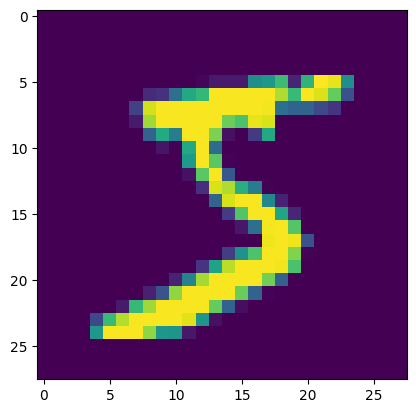

In [55]:
plt.imshow(X_train[0])
plt.show()

In [56]:
X_train = X_train/255
X_test = X_test/255

In [57]:
model = Sequential()

In [ ]:
model.add(Input(shape=(28,28)))

In [59]:
model.add(Flatten())

In [60]:
model.add(Dense(128,activation='relu'))
model.add(Dense(10,activation='softmax'))

In [61]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [62]:
model.compile(loss='sparse_categorical_crossentropy',optimizer='Adam',metrics=['accuracy'])

In [64]:
history = model.fit(epochs=10,x=X_train,y=y_train,validation_split=.2)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9182 - loss: 0.2864 - val_accuracy: 0.9560 - val_loss: 0.1546
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9625 - loss: 0.1259 - val_accuracy: 0.9662 - val_loss: 0.1127
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9746 - loss: 0.0870 - val_accuracy: 0.9710 - val_loss: 0.0938
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9809 - loss: 0.0641 - val_accuracy: 0.9735 - val_loss: 0.0900
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9850 - loss: 0.0497 - val_accuracy: 0.9717 - val_loss: 0.0911
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9885 - loss: 0.0386 - val_accuracy: 0.9743 - val_loss: 0.0887
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9907 - loss: 0.0306 - val_accuracy: 0.9747 - val_loss: 0.0852
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9920 - loss: 0.0257 - 

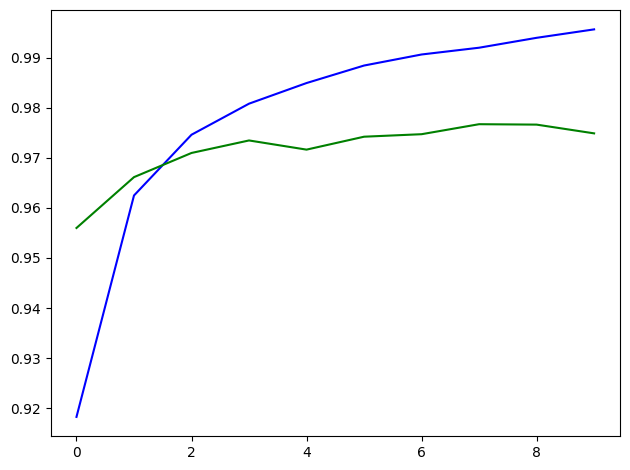

In [70]:
plt.plot(history.history['accuracy'],color = 'b')
plt.plot(history.history['val_accuracy'],color = 'g')
plt.tight_layout()
plt.show()

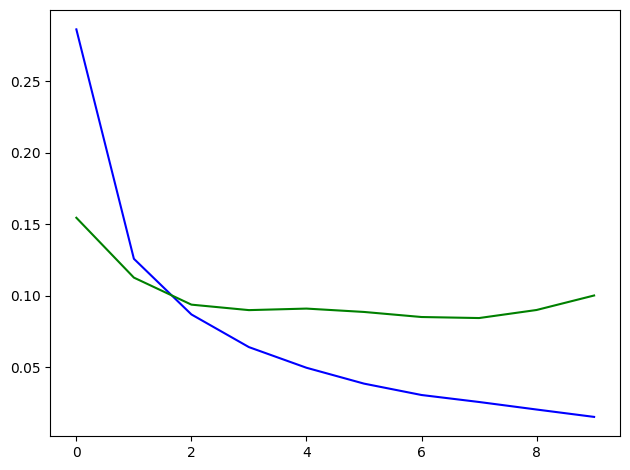

In [71]:
plt.plot(history.history['loss'],color = 'b')
plt.plot(history.history['val_loss'],color = 'g')
plt.tight_layout()
plt.show()

In [72]:
y_probability = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [78]:
y_pred = y_probability.argmax(axis=1)

In [82]:
accuracy_score(y_test,y_pred)

0.9749

In [83]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.99      0.98      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.97      0.97      0.97      1032
           3       0.96      0.98      0.97      1010
           4       0.98      0.97      0.98       982
           5       0.99      0.96      0.97       892
           6       0.98      0.98      0.98       958
           7       0.98      0.96      0.97      1028
           8       0.94      0.99      0.96       974
           9       0.97      0.96      0.96      1009

    accuracy                           0.97     10000
   macro avg       0.98      0.97      0.97     10000
weighted avg       0.98      0.97      0.97     10000

